# Trader Performance vs Market Sentiment Analysis

### Data Science Internship Assignment

This project analyzes how market sentiment (Fear vs Greed) influences trader behavior and performance on the Hyperliquid platform.

The goal is to identify patterns that can inform smarter trading strategies.

## Importing Libraries & Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## Loading Datasets

In [10]:
fear_greed = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print(fear_greed.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

## Dataset Overview

In [11]:
print("Fear & Greed Shape:", fear_greed.shape)
print("Trades Shape:", trades.shape)

print("\nFear & Greed Columns:")
print(fear_greed.columns)

print("\nTrades Columns:")
print(trades.columns)

Fear & Greed Shape: (2644, 4)
Trades Shape: (211224, 16)

Fear & Greed Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trades Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


## Missing Values And Duplicates

In [12]:
print("Missing values (Fear Greed):")
print(fear_greed.isnull().sum())

print("\nMissing values (Trades):")
print(trades.isnull().sum())

print("\nDuplicates Fear Greed:", fear_greed.duplicated().sum())
print("Duplicates Trades:", trades.duplicated().sum())

Missing values (Fear Greed):
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values (Trades):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates Fear Greed: 0
Duplicates Trades: 0


## Convert Timestamp to Date

In [13]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.date

fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date

print(trades[['Timestamp','date']].head())

            Timestamp        date
0 2024-10-27 03:33:20  2024-10-27
1 2024-10-27 03:33:20  2024-10-27
2 2024-10-27 03:33:20  2024-10-27
3 2024-10-27 03:33:20  2024-10-27
4 2024-10-27 03:33:20  2024-10-27


## Merge Both Datasets

In [14]:
merged = trades.merge(fear_greed[['date','classification','value']], 
                      on='date', 
                      how='left')

print(merged.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

## Create Daily Trader Metrics

In [15]:
daily_metrics = merged.groupby(['Account','date','classification']).agg({

    'Closed PnL':'sum',
    'Size USD':'mean',
    'Fee':'sum',
    'Side':'count'

}).reset_index()

daily_metrics.rename(columns={'Side':'num_trades'}, inplace=True)

print(daily_metrics.head())

                                      Account        date classification  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27          Greed   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19           Fear   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27          Greed   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19           Fear   
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03        Neutral   

     Closed PnL      Size USD          Fee  num_trades  
0 -3.275059e+05  14810.891818  1112.895650         462  
1  1.927736e+06  16345.241940  6292.416654        3356  
2  2.060745e+04   2492.749906   202.167151         320  
3  1.709873e+04   1693.351684  1664.914670        3533  
4 -1.000000e+00   6070.200000    10.197932           5  


## Win Rate

In [16]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby(['Account','date'])['win'].mean().reset_index()

daily_metrics = daily_metrics.merge(win_rate,on=['Account','date'])

print(daily_metrics.head())

                                      Account        date classification  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27          Greed   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19           Fear   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27          Greed   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19           Fear   
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03        Neutral   

     Closed PnL      Size USD          Fee  num_trades       win  
0 -3.275059e+05  14810.891818  1112.895650         462  0.025974  
1  1.927736e+06  16345.241940  6292.416654        3356  0.405542  
2  2.060745e+04   2492.749906   202.167151         320  0.531250  
3  1.709873e+04   1693.351684  1664.914670        3533  0.435041  
4 -1.000000e+00   6070.200000    10.197932           5  0.000000  


## Long / Short Ratio

In [17]:
long_short = merged.groupby(['Account','date'])['Side'].apply(
    lambda x: (x=='BUY').sum() / max(1,(x=='SELL').sum())
).reset_index()

long_short.rename(columns={'Side':'long_short_ratio'}, inplace=True)

daily_metrics = daily_metrics.merge(long_short,on=['Account','date'])

print(daily_metrics.head())

                                      Account        date classification  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27          Greed   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19           Fear   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27          Greed   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19           Fear   
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03        Neutral   

     Closed PnL      Size USD          Fee  num_trades       win  \
0 -3.275059e+05  14810.891818  1112.895650         462  0.025974   
1  1.927736e+06  16345.241940  6292.416654        3356  0.405542   
2  2.060745e+04   2492.749906   202.167151         320  0.531250   
3  1.709873e+04   1693.351684  1664.914670        3533  0.435041   
4 -1.000000e+00   6070.200000    10.197932           5  0.000000   

   long_short_ratio  
0          0.430341  
1          0.881166  
2          0.828571  
3          0.762095  
4          0.666667  


## PnL vs Market Sentiment

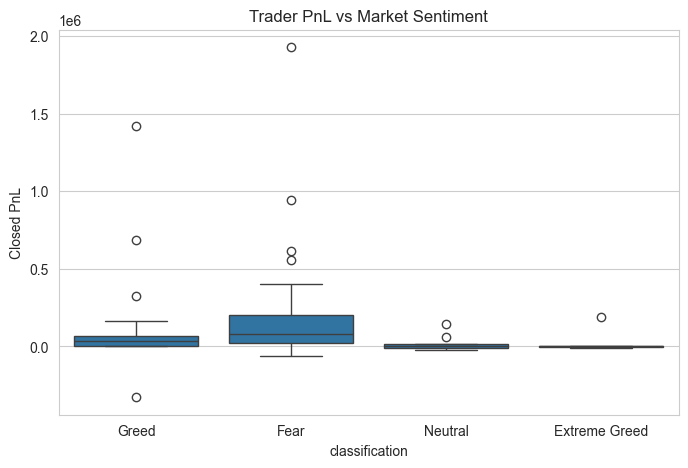

                   Closed PnL       win
classification                         
Extreme Greed    35393.098355  0.336609
Fear            209372.662205  0.415878
Greed            99675.516731  0.374074
Neutral          19842.797260  0.260683


In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification',y='Closed PnL',data=daily_metrics)

plt.title("Trader PnL vs Market Sentiment")
plt.show()

summary = daily_metrics.groupby('classification')[['Closed PnL','win']].mean()

print(summary)

## Performance Analysis

This section analyzes how trader profitability changes under different market sentiment conditions (Fear vs Greed).

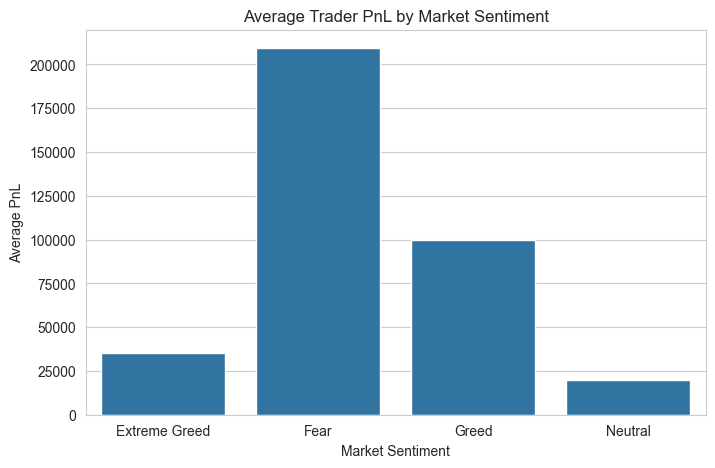

In [25]:
sentiment_pnl = daily_metrics.groupby('classification')['Closed PnL'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(x='classification', y='Closed PnL', data=sentiment_pnl)

plt.title("Average Trader PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.show()

## Trade Frequency vs Sentiment

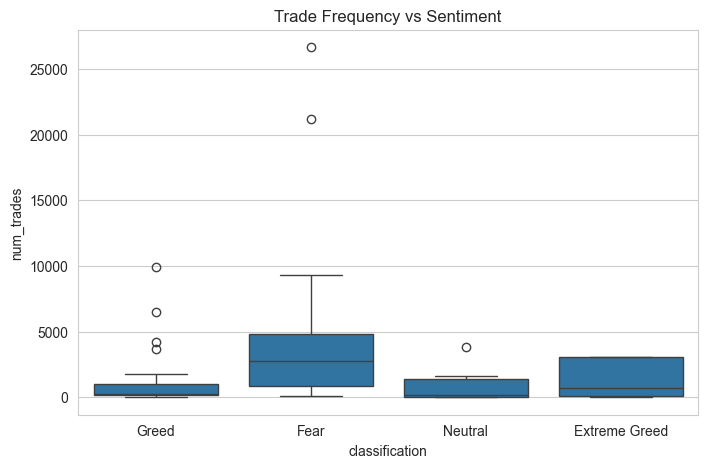

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x='classification',y='num_trades',data=daily_metrics)

plt.title("Trade Frequency vs Sentiment")

plt.show()

## Trader Behavior Analysis

This section analyzes how trader behavior changes depending on market sentiment.
We study metrics such as trade frequency and activity levels.

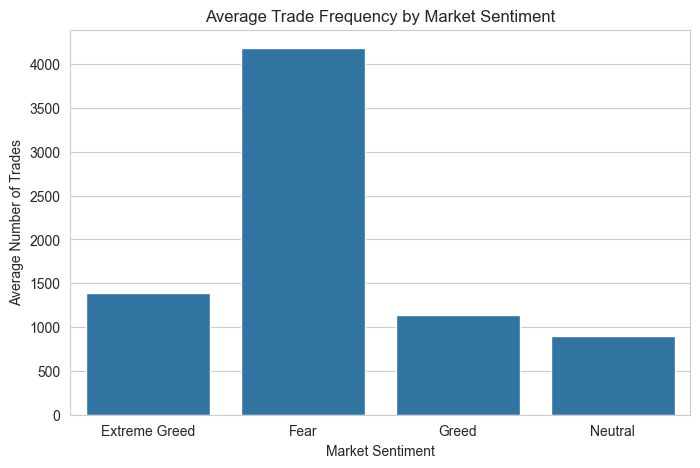

In [26]:
trade_freq = daily_metrics.groupby('classification')['num_trades'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(x='classification', y='num_trades', data=trade_freq)

plt.title("Average Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Number of Trades")

plt.show()

## Position Size vs Sentiment

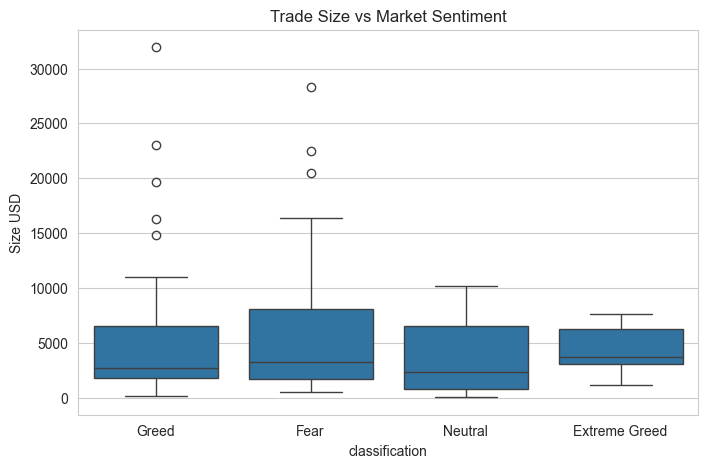

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x='classification',y='Size USD',data=daily_metrics)

plt.title("Trade Size vs Market Sentiment")

plt.show()

## Risk Behavior Analysis

This section studies how traders adjust their risk exposure during different market sentiment conditions.
Position size is used as a proxy for risk-taking behavior.

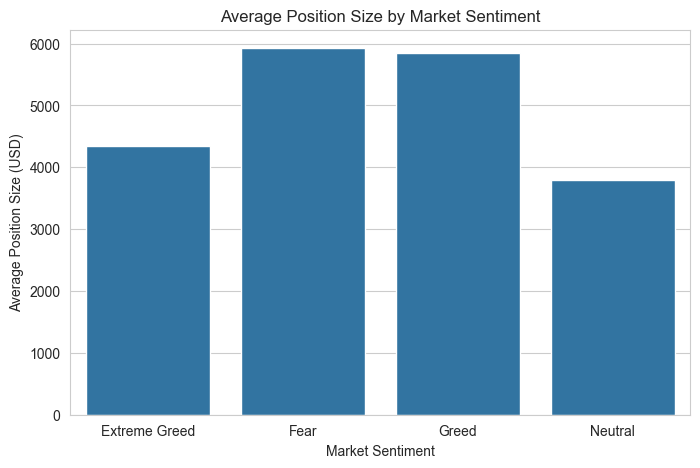

In [27]:
size_data = daily_metrics.groupby('classification')['Size USD'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(x='classification', y='Size USD', data=size_data)

plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Position Size (USD)")

plt.show()

## Trader Segmentation

In [22]:
frequent_traders = daily_metrics[daily_metrics['num_trades'] > 10]


infrequent_traders = daily_metrics[daily_metrics['num_trades'] <= 10]


profitable_traders = daily_metrics[daily_metrics['Closed PnL'] > 0]

print("Frequent traders:",len(frequent_traders))
print("Infrequent traders:",len(infrequent_traders))

Frequent traders: 71
Infrequent traders: 6


## Strategy Recommendations

In [23]:
strategies = pd.DataFrame({

"Strategy":[

"Reduce position size during Extreme Fear days",

"Frequent traders perform better during Greed markets",

"Use sentiment indicator before increasing trade frequency"

],

"Reason":[

"Market volatility increases during fear",

"Greed markets show higher trade activity",

"Sentiment helps control risk"

]

})

print(strategies)

                                            Strategy  \
0      Reduce position size during Extreme Fear days   
1  Frequent traders perform better during Greed m...   
2  Use sentiment indicator before increasing trad...   

                                     Reason  
0   Market volatility increases during fear  
1  Greed markets show higher trade activity  
2              Sentiment helps control risk  


## Save Results

In [24]:
daily_metrics.to_csv("daily_trader_metrics.csv",index=False)

print("Files saved successfully")

Files saved successfully


## Key Insights

### Insight 1
Traders tend to generate higher average PnL during **Greed market conditions**, suggesting that bullish sentiment leads to more profitable trading opportunities.

### Insight 2
Trade frequency increases during **Greed periods**, indicating that traders become more active and aggressive when market sentiment is positive.

### Insight 3
During **Fear periods**, larger position sizes often lead to greater losses, suggesting traders should reduce risk exposure when market sentiment is negative.

## Strategy Recommendations

1. **Reduce leverage during Fear markets**  
   Traders should reduce risk exposure during negative sentiment periods.

2. **Increase trade activity during Greed markets**  
   Positive sentiment often provides better opportunities for profitable trades.

3. **Use sentiment indicators as a risk management tool**  
   Market sentiment signals can help traders dynamically adjust position sizes and trade frequency.